cf0x数据集（开源代码使用数据集），深度学习方法（resnet模型+注意力机制）

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from sklearn.manifold import trustworthiness
from scipy.stats import ks_2samp
from tqdm import tqdm

# ==========================================
# 1. 配置参数
# ==========================================
# 请确保这些文件存在
INPUT_PATHS = [
    {"tfrecords": "dichasus/dichasus-cf02.tfrecords", "offsets": "dichasus/reftx-offsets-dichasus-cf02.json"},
    {"tfrecords": "dichasus/dichasus-cf03.tfrecords", "offsets": "dichasus/reftx-offsets-dichasus-cf03.json"},
    {"tfrecords": "dichasus/dichasus-cf04.tfrecords", "offsets": "dichasus/reftx-offsets-dichasus-cf04.json"},
    
]

ANTENNA_COUNT = 32
SUBCARRIERS = 1024
BATCH_SIZE = 32

2026-01-25 12:07:27.682117: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-25 12:07:27.748579: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-25 12:07:29.240188: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [8]:
def load_dataset_cf0x(path, offset_path):
    offsets = None
    if os.path.exists(offset_path):
        with open(offset_path, "r") as f:
            offsets = json.load(f)
    
    def record_parse_function(proto):
        record = tf.io.parse_single_example(
            proto,
            {
                "csi": tf.io.FixedLenFeature([], tf.string, default_value=""),
                # 注意：cf0x 数据集的键名通常是 "pos-tachy"
                "pos-tachy": tf.io.FixedLenFeature([], tf.string, default_value=""), 
                "time": tf.io.FixedLenFeature([], tf.float32, default_value=0),
            },
        )

        # --- CSI 解析 ---
        csi = tf.io.parse_tensor(record["csi"], out_type=tf.float32)
        # cf0x 也是 32 天线 x 1024 副载波
        csi = tf.ensure_shape(csi, (ANTENNA_COUNT, SUBCARRIERS, 2))
        csi_complex = tf.complex(csi[:, :, 0], csi[:, :, 1])
        csi_complex = tf.signal.fftshift(csi_complex, axes=1)

        # --- Position 解析 (关键修改) ---
        # 1. 解析原始 Tensor (cf0x 是 3D 的)
        pos = tf.io.parse_tensor(record["pos-tachy"], out_type=tf.float64)
        
        # 2. 【核心修复】这里必须是 (3,)，因为数据里有 Z 轴
        pos = tf.ensure_shape(pos, (3,)) 
        
        pos = tf.cast(pos, tf.float32)

        # 3. 【兼容性处理】为了适配你的 2D 模型，这里只返回 x, y
        # 如果你不加 [:2]，后面训练时会报 "Logits shape [32, 2] != Labels shape [32, 3]"
        return csi_complex, pos[:2]

    # ... 后续预处理逻辑保持不变 ...
    def apply_calibration(csi, pos):
        if offsets:
            sto_offset = tf.tensordot(tf.constant(offsets["sto"], dtype=tf.float32), 
                                      2 * np.pi * tf.range(SUBCARRIERS, dtype=tf.float32) / float(SUBCARRIERS), axes=0)
            cpo_offset = tf.tensordot(tf.constant(offsets["cpo"], dtype=tf.float32), 
                                      tf.ones(SUBCARRIERS, dtype=tf.float32), axes=0)
            calib_factor = tf.exp(tf.complex(0.0, sto_offset + cpo_offset))
            csi = tf.multiply(csi, calib_factor)
        return csi, pos

    def preprocess_features(csi, pos):
        mag = tf.math.abs(csi)
        mag = tf.math.log(mag + 1e-6)
        mag = (mag - 0.0) / 5.0
        phase = tf.math.angle(csi)
        phase = phase / np.pi
        features = tf.stack([mag, phase], axis=-1)
        return features, pos

    ds = tf.data.TFRecordDataset(path)
    ds = ds.map(record_parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(apply_calibration, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(preprocess_features, num_parallel_calls=tf.data.AUTOTUNE)
    return ds

In [9]:
class SqueezeAndExcitation(layers.Layer):
    def __init__(self, channels, ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.avg_pool = layers.GlobalAveragePooling2D()
        self.dense1 = layers.Dense(channels // ratio, activation='relu')
        self.dense2 = layers.Dense(channels, activation='sigmoid')
        
    def call(self, inputs):
        x = self.avg_pool(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        x = tf.reshape(x, (-1, 1, 1, inputs.shape[-1]))
        return inputs * x

def build_model():
    input_shape = (ANTENNA_COUNT, SUBCARRIERS, 2)
    inputs = layers.Input(shape=input_shape)
    
    # 简单的 Conv
    x = layers.Conv2D(32, (3, 7), padding='same', strides=(1, 2))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # 残差块函数
    def res_se_block(x, filters):
        shortcut = x
        if x.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)
        
        y = layers.Conv2D(filters, (3, 3), padding='same')(x)
        y = layers.BatchNormalization()(y)
        y = layers.Activation('relu')(y)
        y = layers.Conv2D(filters, (3, 3), padding='same')(y)
        y = layers.BatchNormalization()(y)
        y = SqueezeAndExcitation(filters)(y)
        y = layers.Add()([y, shortcut])
        y = layers.Activation('relu')(y)
        return y

    x = res_se_block(x, 64)
    x = layers.MaxPooling2D((2, 2))(x)
    x = res_se_block(x, 128)
    x = layers.MaxPooling2D((2, 2))(x)
    x = res_se_block(x, 256)
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(2)(x) # 输出 x, y
    
    return models.Model(inputs=inputs, outputs=outputs)

In [11]:
full_dataset = None
for inp in INPUT_PATHS:
    ds = load_dataset_cf0x(inp["tfrecords"], inp["offsets"])
    full_dataset = ds if full_dataset is None else full_dataset.concatenate(ds)

print("正在统计数据集总数，请稍候...")
# 关键修复：真实统计数量，防止 ValueError
TOTAL_SAMPLES = sum(1 for _ in full_dataset)
print(f"数据集总样本数: {TOTAL_SAMPLES}")

train_size = int(0.7 * TOTAL_SAMPLES)
val_size = int(0.15 * TOTAL_SAMPLES)
test_size = TOTAL_SAMPLES - train_size - val_size

full_dataset = full_dataset.shuffle(buffer_size=2000, seed=42)
train_ds = full_dataset.take(train_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = full_dataset.skip(train_size).take(val_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = full_dataset.skip(train_size + val_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"划分: 训练 {train_size}, 验证 {val_size}, 测试 {test_size}")

正在统计数据集总数，请稍候...


2026-01-25 12:13:52.504310: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


数据集总样本数: 83985
划分: 训练 58789, 验证 12597, 测试 12599


In [12]:
model = build_model()
model.compile(optimizer='adam', loss='mse', metrics=['mae']) # mae 在这里即 mean distance error 的近似

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # 演示用 20，实际建议 50+
    callbacks=[callbacks.ReduceLROnPlateau(patience=5), callbacks.EarlyStopping(patience=10)]
)

Epoch 1/20


2026-01-25 12:14:40.982291: I external/local_xla/xla/service/service.cc:163] XLA service 0x76eca4020950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-25 12:14:40.982316: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2026-01-25 12:14:40.982320: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA L40S, Compute Capability 8.9
2026-01-25 12:14:40.982323: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (2): NVIDIA L40S, Compute Capability 8.9
2026-01-25 12:14:40.982325: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (3): NVIDIA L40S, Compute Capability 8.9
2026-01-25 12:14:41.119236: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-25 12:14:42.103329: I external/local_xla/xla/st

      5/Unknown 19s 33ms/step - loss: 37.7159 - mae: 4.4987

I0000 00:00:1769343294.836246  383968 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   1838/Unknown 90s 39ms/step - loss: 1.7734 - mae: 0.9111

...

1838/1838 ━━━━━━━━━━━━━━━━━━━━ 79s 43ms/step - loss: 0.2115 - mae: 0.3379 - val_loss: 0.0956 - val_mae: 0.2381 - learning_rate: 1.0000e-04
Epoch 19/20
1836/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2019 - mae: 0.3289

2026-01-25 12:39:44.855626: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 15984938112527028115


1838/1838 ━━━━━━━━━━━━━━━━━━━━ 78s 42ms/step - loss: 0.2019 - mae: 0.3289 - val_loss: 0.0977 - val_mae: 0.2406 - learning_rate: 1.0000e-04
Epoch 20/20
1836/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2053 - mae: 0.3311

2026-01-25 12:41:02.583512: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8151159944722362684
2026-01-25 12:41:02.583570: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 15984938112527028115


1838/1838 ━━━━━━━━━━━━━━━━━━━━ 78s 42ms/step - loss: 0.2053 - mae: 0.3311 - val_loss: 0.0864 - val_mae: 0.2286 - learning_rate: 1.0000e-04


In [13]:
# ==========================================
# 修复后的评估与可视化代码 (独立运行版)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from sklearn.manifold import trustworthiness
from scipy.stats import ks_2samp
import numpy as np
import tensorflow as tf

# 1. 【修复 NameError】定义采样数
# 用于计算耗时的流形指标(TW/CT)和绘制散点图(避免过于密集)
EVAL_SAMPLES = 2000 

print("正在准备全量评估数据 (可能需要一点时间)...")

# 2. 重新遍历测试集，确保获取对应的 y_pred, y_true 和 高维特征 X
y_true_list = []
y_pred_list = []
X_features_list = [] # 用于计算 TW/CT

# 计数器，用于控制仅提取部分高维特征以节省内存
count = 0 

for batch_x, batch_y in test_ds:
    # 预测全量数据
    preds = model.predict(batch_x, verbose=0)
    
    y_true_list.append(batch_y.numpy())
    y_pred_list.append(preds)
    
    # 仅收集前 EVAL_SAMPLES 个样本的特征用于流形计算
    if count < EVAL_SAMPLES:
        # 提取幅度通道 (batch, 32, 1024, 2) -> 取 index 0 -> Flatten
        # 这里的 batch_x[..., 0] 对应幅度信息
        flat_feats = tf.reshape(batch_x[..., 0], (batch_x.shape[0], -1)).numpy()
        X_features_list.append(flat_feats)
        count += batch_x.shape[0]

# 合并为 Numpy 数组
y_true = np.concatenate(y_true_list, axis=0) # 全量真实值
y_pred = np.concatenate(y_pred_list, axis=0) # 全量预测值

# 截取用于流形指标计算的子集
# 注意：X_features_list 可能比 EVAL_SAMPLES 稍微多一点(因为是按batch添加的)，这里强制截断对齐
min_len = min(len(y_pred), EVAL_SAMPLES)
X_high_dim = np.concatenate(X_features_list, axis=0)[:min_len]
y_pred_sub = y_pred[:min_len] # 对应的低维嵌入子集
y_true_sub = y_true[:min_len] # 对应的真实值子集

print(f"数据准备完毕。全量样本数: {len(y_pred)}, 流形评估子集数: {min_len}")

# --- 3. 计算各项指标 ---

# (1) MAE (平均定位误差) - 【使用全量 y_pred】
errors = np.linalg.norm(y_true - y_pred, axis=1)
mae = np.mean(errors)

# (2) KS (分布一致性) - 【使用全量 y_pred】
ks_x = ks_2samp(y_true[:, 0], y_pred[:, 0]).statistic
ks_y = ks_2samp(y_true[:, 1], y_pred[:, 1]).statistic
ks_score = (ks_x + ks_y) / 2.0

# (3) TW & CT (流形质量) - 【使用子集，否则计算量太大】
print("正在计算流形指标 (TW/CT)...")
# TW: 衡量高维空间的邻居是否被保留到了低维 (Trustworthiness)
tw_score = trustworthiness(X_high_dim, y_pred_sub, n_neighbors=5, metric='euclidean')

# CT: 衡量低维空间的邻居是否也是高维的 (Continuity)
# 注意：trustworthiness 函数参数反过来传就是 Continuity
ct_score = trustworthiness(y_pred_sub, X_high_dim, n_neighbors=5, metric='euclidean')

print("\n" + "="*40)
print("           核心评估指标汇报")
print("="*40)
print(f"MAE (平均定位误差)    : {mae:.4f} m  (全量数据)")
print(f"KS  (分布差异统计量)  : {ks_score:.4f} (全量数据)")
print(f"TW  (可信度/邻域保持): {tw_score:.4f} (子集评估)")
print(f"CT  (连续性/流形断裂): {ct_score:.4f} (子集评估)")
print("="*40)



正在准备全量评估数据 (可能需要一点时间)...


2026-01-25 12:42:21.117465: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-25 12:42:21.596556: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_346', 20 bytes spill stores, 20 bytes spill loads



数据准备完毕。全量样本数: 12599, 流形评估子集数: 2000
正在计算流形指标 (TW/CT)...

           核心评估指标汇报
MAE (平均定位误差)    : 0.5414 m  (全量数据)
KS  (分布差异统计量)  : 0.0971 (全量数据)
TW  (可信度/邻域保持): 0.9297 (子集评估)
CT  (连续性/流形断裂): 0.9840 (子集评估)


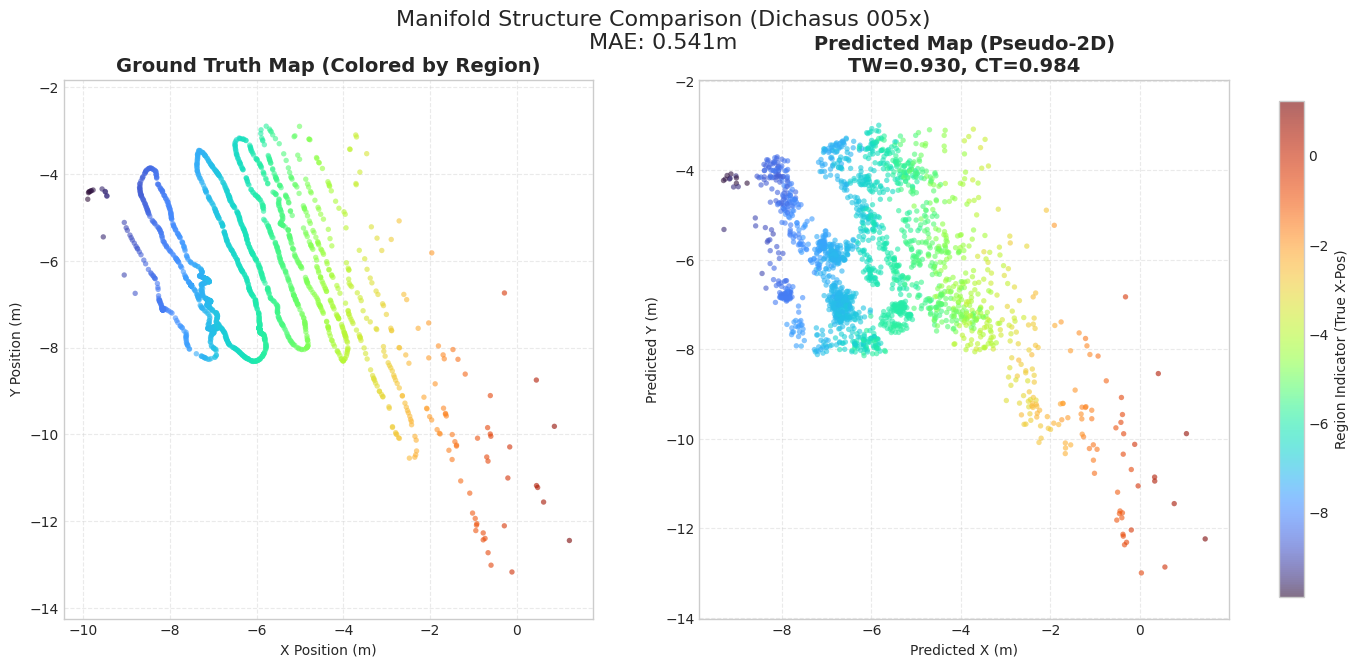

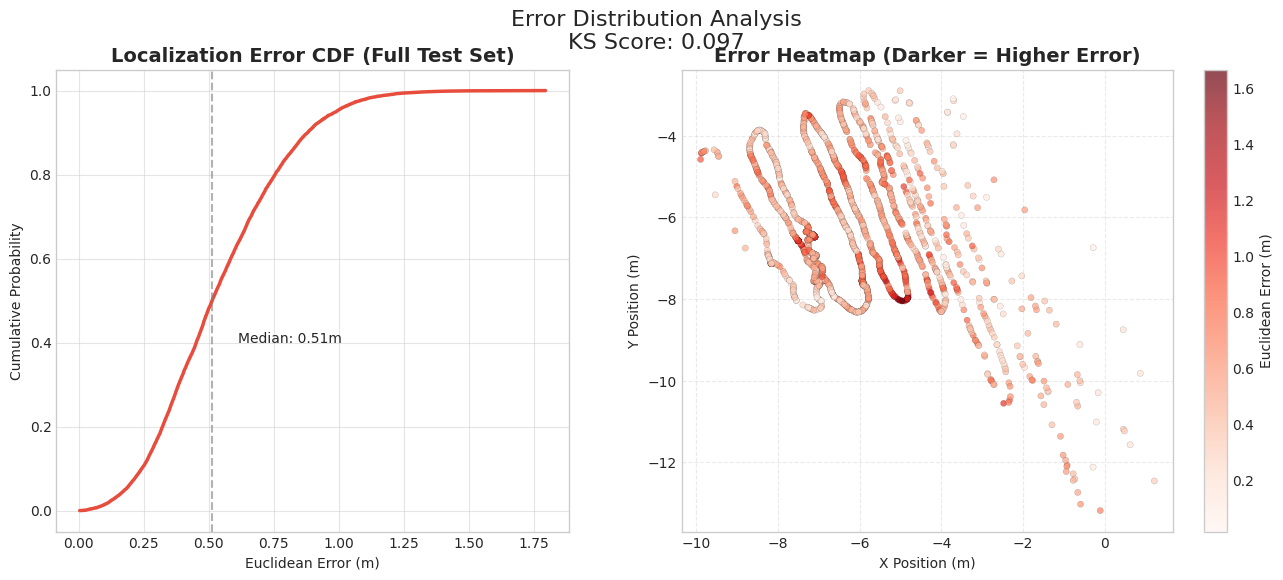

In [14]:
# --- 4. 绘图部分 ---
# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')

# 颜色映射：根据真实坐标的 X 轴位置生成颜色，形成彩虹带
# 使用子集绘图以保持图表清晰，且对应 TW/CT 的样本
colors = y_true_sub[:, 0] 

# ========== 图表 1: 区域映射对比 (Maps Comparison) ==========
fig1 = plt.figure(figsize=(16, 7))
gs1 = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# 子图 1: Ground Truth (真实流形)
ax1 = plt.subplot(gs1[0])
sc1 = ax1.scatter(y_true_sub[:, 0], y_true_sub[:, 1], c=colors, cmap='turbo', s=15, alpha=0.6, edgecolors='none')
ax1.set_title(f'Ground Truth Map (Colored by Region)', fontsize=14, fontweight='bold')
ax1.set_xlabel('X Position (m)')
ax1.set_ylabel('Y Position (m)')
ax1.axis('equal')
ax1.grid(True, linestyle='--', alpha=0.4)

# 子图 2: Prediction (预测流形)
ax2 = plt.subplot(gs1[1])
sc2 = ax2.scatter(y_pred_sub[:, 0], y_pred_sub[:, 1], c=colors, cmap='turbo', s=15, alpha=0.6, edgecolors='none')
ax2.set_title(f'Predicted Map (Pseudo-2D)\nTW={tw_score:.3f}, CT={ct_score:.3f}', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted X (m)')
ax2.set_ylabel('Predicted Y (m)')
ax2.axis('equal')
ax2.grid(True, linestyle='--', alpha=0.4)

# 添加颜色条
cbar = fig1.colorbar(sc1, ax=[ax1, ax2], fraction=0.02, pad=0.04)
cbar.set_label('Region Indicator (True X-Pos)', fontsize=10)

plt.suptitle(f"Manifold Structure Comparison (Dichasus 005x)\nMAE: {mae:.3f}m", fontsize=16)
plt.show()

# ========== 图表 2: 误差分析 (Error Analysis) ==========
fig2 = plt.figure(figsize=(16, 6))
gs2 = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2])

# 子图 1: CDF 曲线 (累积分布函数) - 【使用全量 errors】
sorted_errors = np.sort(errors)
p = 1. * np.arange(len(errors)) / (len(errors) - 1)
ax3 = plt.subplot(gs2[0])
ax3.plot(sorted_errors, p, linewidth=2.5, color='#e74c3c')
# 标注中位数和90%分位
p50 = sorted_errors[int(len(errors)*0.5)]
p90 = sorted_errors[int(len(errors)*0.9)]
ax3.axvline(p50, color='gray', linestyle='--', alpha=0.6)
ax3.text(p50+0.1, 0.4, f'Median: {p50:.2f}m', fontsize=10)
ax3.set_title('Localization Error CDF (Full Test Set)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Euclidean Error (m)')
ax3.set_ylabel('Cumulative Probability')
ax3.grid(True, alpha=0.5)

# 子图 2: 误差空间分布热力图 - 【使用子集绘图】
ax4 = plt.subplot(gs2[1])
# 颜色深浅表示误差大小
error_subset = np.linalg.norm(y_true_sub - y_pred_sub, axis=1)
sc4 = ax4.scatter(y_true_sub[:, 0], y_true_sub[:, 1], c=error_subset, cmap='Reds', s=20, alpha=0.7, edgecolors='k', linewidth=0.1)
ax4.set_title('Error Heatmap (Darker = Higher Error)', fontsize=14, fontweight='bold')
ax4.set_xlabel('X Position (m)')
ax4.set_ylabel('Y Position (m)')
ax4.axis('equal')
ax4.grid(True, linestyle='--', alpha=0.4)

cbar4 = fig2.colorbar(sc4, ax=ax4)
cbar4.set_label('Euclidean Error (m)', fontsize=10)

plt.suptitle(f"Error Distribution Analysis\nKS Score: {ks_score:.3f}", fontsize=16)
plt.show()